e:\BITSOM\Module 3 Python\Practice\practice1.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1049.04it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


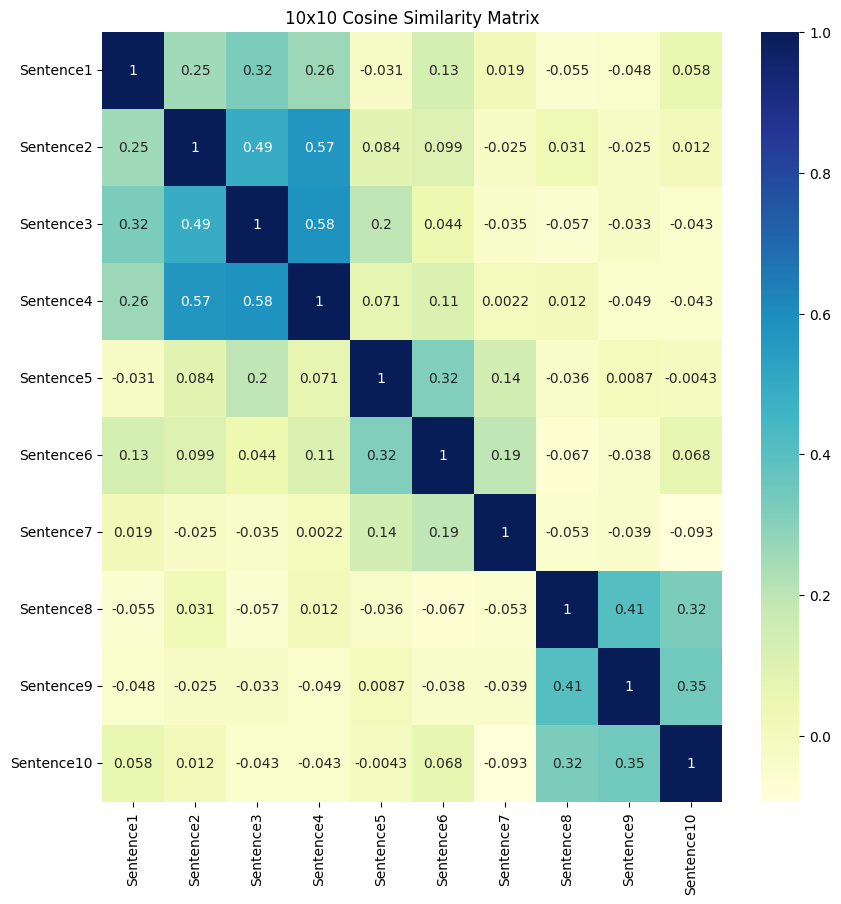

Query: The bowler took three wickets in one over

Rank 1 | Score: 0.6546 | Sentence : Brett Lee was one of the fastest bowlers and took many wickets.
Rank 2 | Score: 0.6371 | Sentence : Harbhajan once took 4 wickets in a row.


In [ ]:
from sentence_transformers import SentenceTransformer , util     #importing the sentence transformation function.
import torch                                                     # importig pyTorch for working on the model all-MiniLM-L6-v2 as it is made on pyTorch as base.
import matplotlib.pyplot as plt                                  # imporing matplotlib.pyplot to plot the required cosine search similarity matrix with the corresponding axes
import seaborn as sns                                            # importing seaborn to generate the heatmap from the generated cosine search matrix



model = SentenceTransformer('all-MiniLM-L6-v2')                  # Selecting the transformation model


sentences = [

    # Cricket
    "The captain decided to field first after winning the toss.",
    "Sachin Tendulkar hit a massive six over long-on followed by a four.",
    "Brett Lee was one of the fastest bowlers and took many wickets.",
    "Harbhajan once took 4 wickets in a row.",

    # Cooking

    "Slow-cooking the onions helps in caramelizing them perfectly.",
    "Always rest the dough after kneading it.",
    "White sauce pasta is made delicious by using good quality cheese",

    # Cybersecurity

    "Multi-factor authentication significantly reduces the risk of unauthorized access.",
    "Phishing emails often mimic official bank communications to steal credentials.",
    "Keyloggers track the sequence of pressing of physical keyboard keys for stealing the passwords, therefore we must always use virtual keyboards."

]

embedding = model.encode(sentences, convert_to_tensor=True)   # Convert the sentences and embedd them in vector DB

#Compute the cosine similarity and store
cosine_scores = util.cos_sim(embedding, embedding)


# Plotting the Heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(cosine_scores.cpu().numpy(), annot=True, cmap='YlGnBu', # The cosine similarity data is in tensor format and is to be converted by numpy for processing by seraborn
            xticklabels=[f"Sentence{i+1}" for i in range(10)],  # Defining x-axis labels
            yticklabels=[f"Sentence{i+1}" for i in range(10)])  # Defining y-axis labels
plt.title("10x10 Cosine Similarity Matrix")                     # Defining heatmap title
plt.show()                                                      # Display the heatmap

query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)   # Convert the query and store it.

# Find top 2 matches using cosine similarity
hits = util.semantic_search(query_embedding, embedding, top_k=2)

print(f"Query: {query}\n")
for i, result in enumerate(hits[0],1):
    score = result['score']
    sentence = sentences[result['corpus_id']]

    print(f"Rank {i} | Score: {score:.4f} | Sentence : {sentence}")




